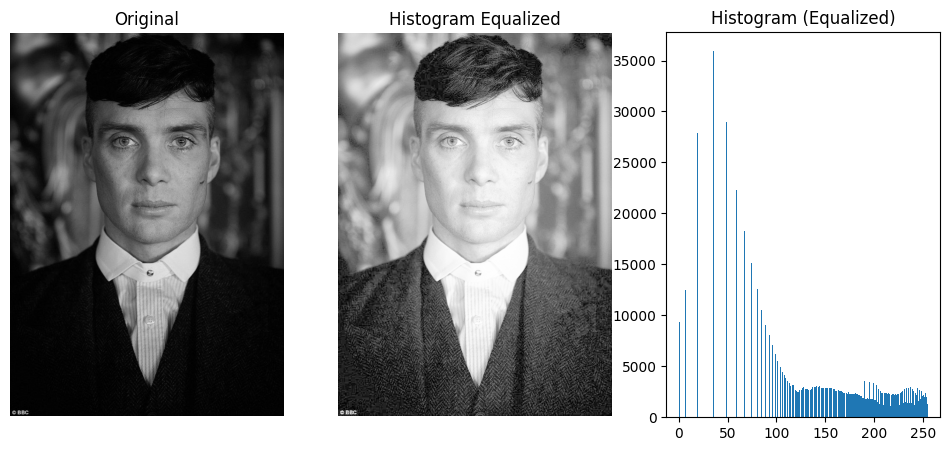

In [ ]:
import cv2
import matplotlib.pyplot as plt

img = cv2.imread("/content/sample_data(3).jpg", 0)

if img is None:
    print("Image not found. Check the file path.")
else:
    he_img = cv2.equalizeHist(img)

    plt.figure(figsize=(12,5))

    plt.subplot(1,3,1)
    plt.title("Original")
    plt.imshow(img, cmap='gray')
    plt.axis("off")

    plt.subplot(1,3,2)
    plt.title("Histogram Equalized")
    plt.imshow(he_img, cmap='gray')
    plt.axis("off")

    plt.subplot(1,3,3)
    plt.title("Histogram (Equalized)")
    plt.hist(he_img.ravel(), 256)
    plt.show()

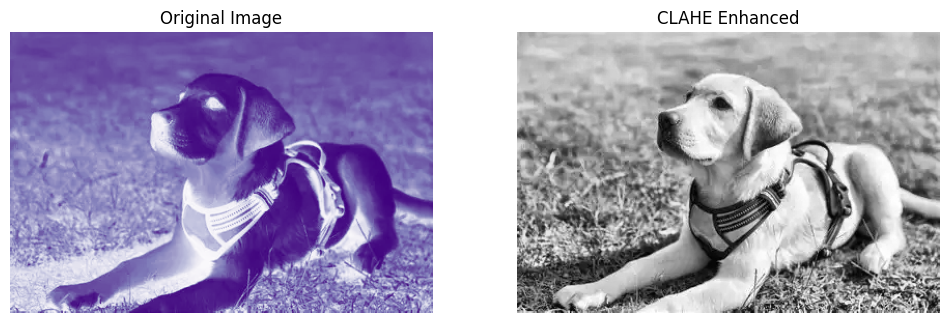

In [ ]:
#Point Processing
#CLAHE
import cv2
import matplotlib.pyplot as plt
# Load grayscale image
img = cv2.imread("/content/sample_data.webp", 0)
# Create CLAHE object
clahe = cv2.createCLAHE(clipLimit= 2.0, tileGridSize=(8,8))
# Apply enchancement
clahe_img = clahe.apply(img)
# Plot
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.title('Original Image')
plt.imshow(img, cmap='Purples')
plt.axis("off")

plt.subplot(1,2,2)
plt.title('CLAHE Enhanced')
plt.axis("off")
plt.imshow(clahe_img, cmap='gray')

plt.show()

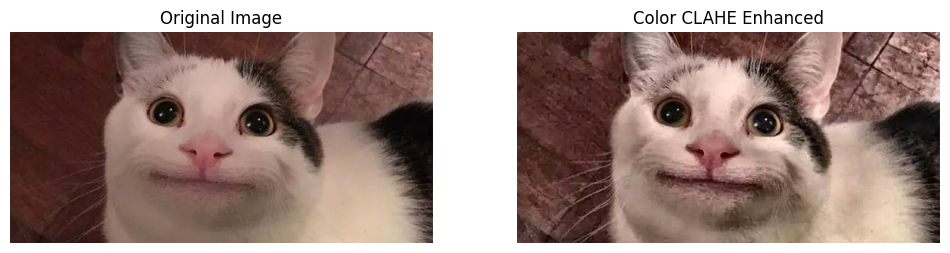

In [ ]:
# Point Processing
# CLAHE on Color Image
import cv2
import matplotlib.pyplot as plt

# Load color image
img = cv2.imread("/content/sample_data(2).jpeg")
# Convert to YCrCb (CLAHE works on Y channel)
img_ycrcb = cv2.cvtColor(img, cv2.COLOR_BGR2YCrCb)
# Split channels
Y, Cr, Cb = cv2.split(img_ycrcb)
# Create CLAHE object
clahe = cv2.createCLAHE(clipLimit=2.5, tileGridSize=(8,8))
# Apply CLAHE on Y channel
Y_clahe = clahe.apply(Y)
# Merge enhanced Y with original Cr, Cb
img_clahe = cv2.merge((Y_clahe, Cr, Cb))
img_clahe = cv2.cvtColor(img_clahe, cv2.COLOR_YCrCb2BGR)
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.title("Original Image")
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.axis("off")

plt.subplot(1,2,2)
plt.title("Color CLAHE Enhanced")
plt.imshow(cv2.cvtColor(img_clahe, cv2.COLOR_BGR2RGB))
plt.axis("off")

plt.show()

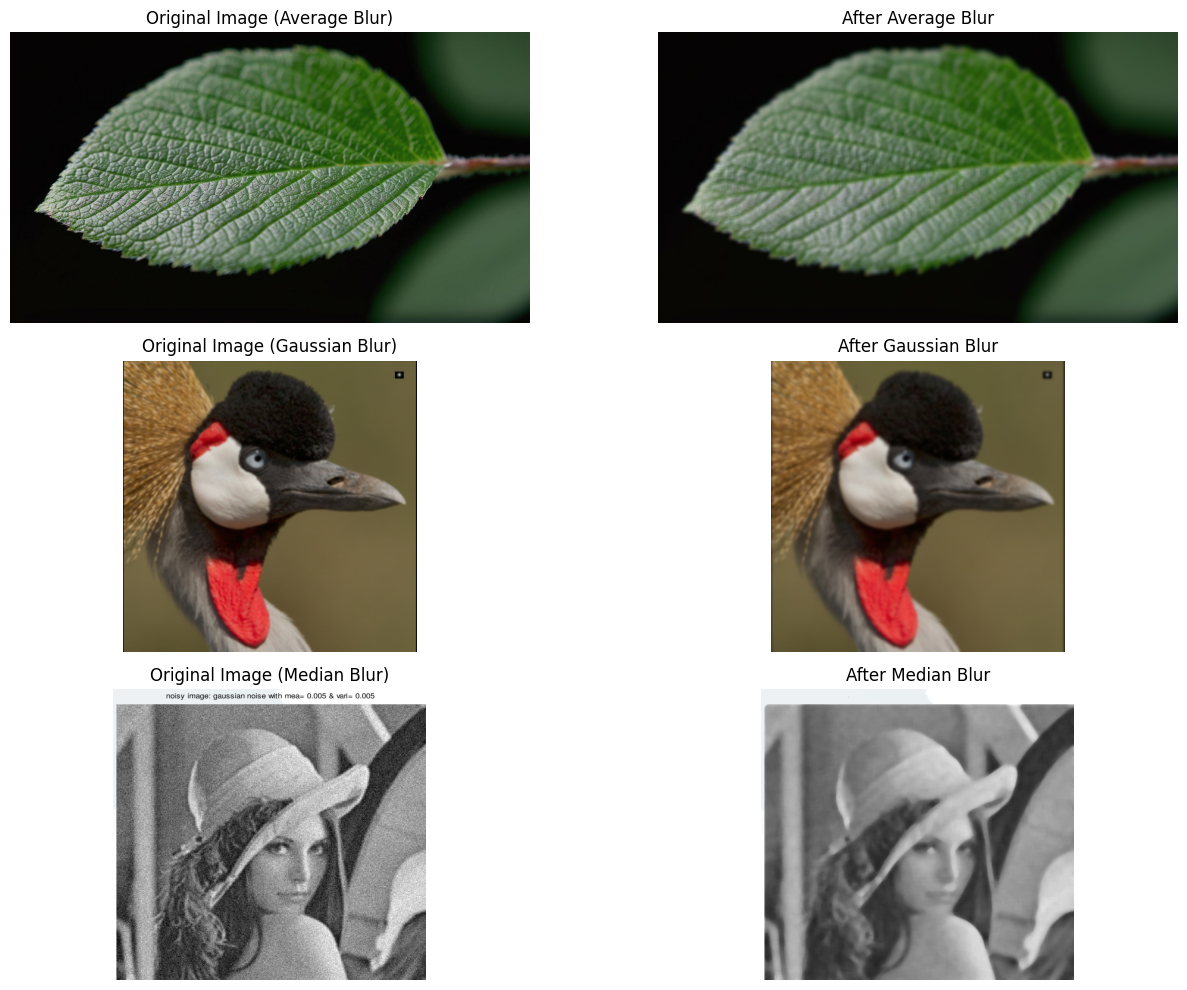

In [ ]:
# Spatial Domain Filtering - Smoothing
import cv2
import matplotlib.pyplot as plt

# Load images
img_avg = cv2.imread("/content/sample_data(5).jpeg")
img_gauss = cv2.imread("/content/sample_data(6).png")
img_median = cv2.imread("/content/sample_data(8).png")

# Check if images loaded properly
if img_avg is None or img_gauss is None or img_median is None:
    print("Error: One or more images not found. Check file paths!")
    exit()

# Convert BGR → RGB for display
img_avg_rgb = cv2.cvtColor(img_avg, cv2.COLOR_BGR2RGB)
img_gauss_rgb = cv2.cvtColor(img_gauss, cv2.COLOR_BGR2RGB)
img_median_rgb = cv2.cvtColor(img_median, cv2.COLOR_BGR2RGB)

# Apply smoothing filters

# 1. Average Blur
avg_blur = cv2.blur(img_avg, (15, 15))
avg_blur_rgb = cv2.cvtColor(avg_blur, cv2.COLOR_BGR2RGB)

# 2. Gaussian Blur
gaussian_blur = cv2.GaussianBlur(img_gauss, (5, 5), 0)
gaussian_blur_rgb = cv2.cvtColor(gaussian_blur, cv2.COLOR_BGR2RGB)

# 3. Median Blur
median_blur = cv2.medianBlur(img_median, 15)
median_blur_rgb = cv2.cvtColor(median_blur, cv2.COLOR_BGR2RGB)

# Display results
plt.figure(figsize=(14, 10))

# Average Blur
plt.subplot(3, 2, 1)
plt.imshow(img_avg_rgb)
plt.title("Original Image (Average Blur)")
plt.axis("off")

plt.subplot(3, 2, 2)
plt.imshow(avg_blur_rgb)
plt.title("After Average Blur")
plt.axis("off")

# Gaussian Blur
plt.subplot(3, 2, 3)
plt.imshow(img_gauss_rgb)
plt.title("Original Image (Gaussian Blur)")
plt.axis("off")

plt.subplot(3, 2, 4)
plt.imshow(gaussian_blur_rgb)
plt.title("After Gaussian Blur")
plt.axis("off")

# Median Blur
plt.subplot(3, 2, 5)
plt.imshow(img_median_rgb)
plt.title("Original Image (Median Blur)")
plt.axis("off")

plt.subplot(3, 2, 6)
plt.imshow(median_blur_rgb)
plt.title("After Median Blur")
plt.axis("off")

plt.tight_layout()
plt.show()

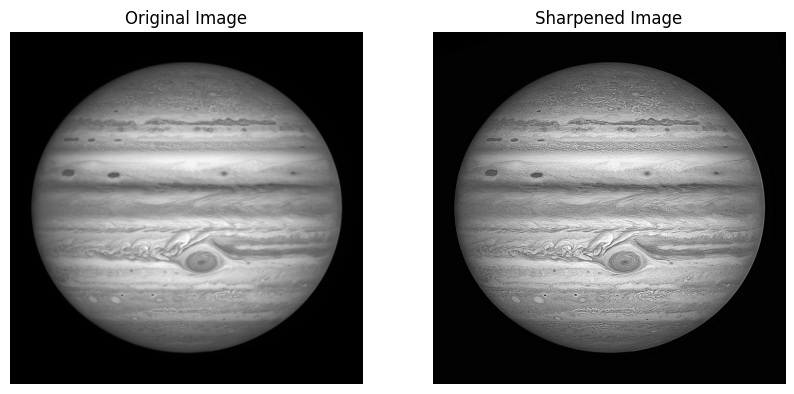

In [3]:
import cv2
import matplotlib.pyplot as plt
import numpy as np
img =cv2.imread("/content/sample_data 10.png",0)
#Sharpening kernal (simple 3x3 filter)
kernel=np.array([[-1,-1,-1],
                 [-1,9,-1],
                 [-1,-1,-1]])
#Apply sharpening
sharpened=cv2.filter2D(img,-1,kernel)
plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
plt.imshow(img,cmap='gray')
plt.title("Original Image")
plt.axis('off')
plt.subplot(1,2,2)
plt.title("Sharpened Image")
plt.imshow(sharpened, cmap='gray')
plt.axis('off')
plt.show()

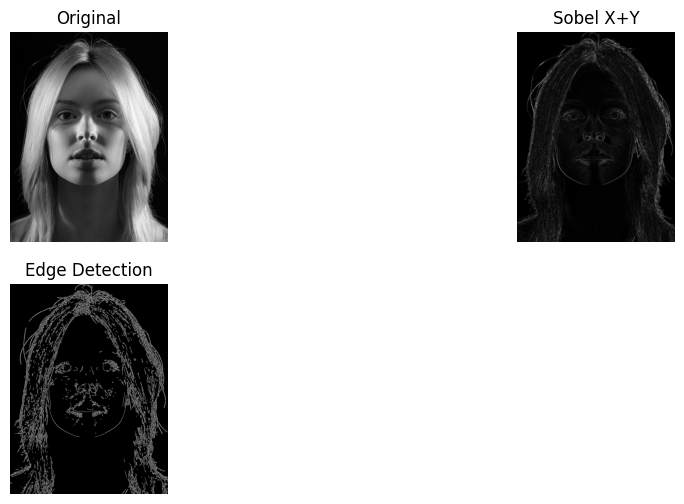

In [12]:
# Spatial Domain Filtering
import cv2
import matplotlib.pyplot as plt

img=cv2.imread("/content/sample_data(11).jpg",0)

# Sobel Edge Detection
sobel_x=cv2.Sobel(img, cv2.CV_64F,1,0,ksize=3)
sobel_y=cv2.Sobel(img, cv2.CV_64F,0,1,ksize=3)
sobel_xy=cv2.magnitude(sobel_x,sobel_y)

# Canny Edge Detector
canny_edges=cv2.Canny(img,100,200)

plt.figure(figsize=(12,6))
plt.subplot(2,2,1)
plt.title("Original")
plt.imshow(img,cmap='gray')
plt.axis('off')
plt.subplot(2,2,2)
plt.title("Sobel X+Y")
plt.imshow(sobel_xy,cmap='gray')
plt.axis('off')
plt.subplot(2,2,3)
plt.title("Edge Detection")
plt.imshow(canny_edges,cmap='gray')
plt.axis('off')
plt.show()